# 3. What drives review scores?

Olist asks customers for a 1-5 star review after delivery. This notebook asks which order characteristics are associated with lower scores: delivery delay, price, freight cost, multi-seller orders, and category.

**Sample:** delivered orders that have a review (latest review per order).

**Model:** OLS of score on the predictors, with heteroskedasticity-robust (HC3) standard errors. Review scores are ordinal and bunched at 5, so OLS is a simplification. As a check I also fit a logistic regression for the outcome a manager actually cares about: a **bad review (1 or 2 stars)**.

In [1]:
import pathlib
import sys

sys.path.insert(0, str(pathlib.Path.cwd().parent))  # repo root, for `analysis` and `common`

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

from common.db import query

In [2]:
df = query("""
select
    o.order_id,
    o.review_score,
    o.delay_days,
    o.delivery_days,
    o.items_value,
    o.freight_value,
    o.items_count,
    o.sellers_count,
    fi.category
from marts.fct_orders o
left join marts.fct_order_items fi
    on fi.order_id = o.order_id and fi.order_item_id = 1
where o.is_delivered
  and o.review_score is not null
  and o.items_value > 0
""")

top_cats = df["category"].value_counts().index[:15]
df = df.assign(
    days_late=df["delay_days"].clip(lower=0).astype(float),
    days_early=(-df["delay_days"]).clip(lower=0).astype(float),
    log_price=np.log(df["items_value"].astype(float)),
    freight_share=(df["freight_value"] / (df["items_value"] + df["freight_value"])).astype(float),
    multi_item=(df["items_count"] > 1).astype(int),
    multi_seller=(df["sellers_count"] > 1).astype(int),
    cat=np.where(df["category"].isin(top_cats), df["category"], "other"),
    bad_review=(df["review_score"] <= 2).astype(int),
)
print(f"{len(df):,} reviewed, delivered orders")
df["review_score"].value_counts(normalize=True).sort_index()

95,824 reviewed, delivered orders


review_score
1    0.097606
2    0.030462
3    0.082610
4    0.197174
5    0.592148
Name: proportion, dtype: float64

Delay is split into *days late* and *days early* because the relationship is unlikely to be symmetric: arriving a week late should hurt a lot more than arriving a week early helps.

In [3]:
formula = "review_score ~ days_late + days_early + log_price + freight_share + multi_item + multi_seller + C(cat)"
ols = smf.ols(formula, data=df).fit(cov_type="HC3")

keep = ["days_late", "days_early", "log_price", "freight_share", "multi_item", "multi_seller"]
coef = pd.DataFrame({
    "coef": ols.params[keep],
    "ci_low": ols.conf_int().loc[keep, 0],
    "ci_high": ols.conf_int().loc[keep, 1],
    "p_value": ols.pvalues[keep],
})
print(f"R-squared: {ols.rsquared:.3f}   n = {int(ols.nobs):,}")
coef

R-squared: 0.120   n = 95,824


,coef,ci_low,ci_high,p_value
days_late,-0.063780,-0.071746,-0.055815,1.652192e-55
days_early,0.024319,0.022916,0.025722,7.363716e-253
log_price,-0.142633,-0.157315,-0.127952,7.802427e-81
freight_share,-1.065633,-1.174464,-0.956802,4.375966e-82
multi_item,-0.370576,-0.406463,-0.334689,4.453044e-91
multi_seller,-1.008649,-1.107264,-0.910034,2.151104e-89


## Residual checks

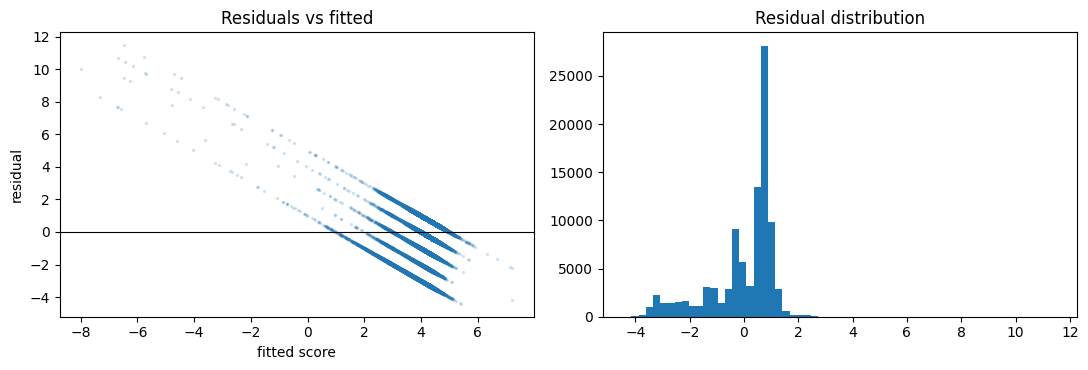

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].scatter(ols.fittedvalues, ols.resid, s=2, alpha=0.15)
axes[0].axhline(0, color="k", lw=0.8)
axes[0].set_xlabel("fitted score")
axes[0].set_ylabel("residual")
axes[0].set_title("Residuals vs fitted")
axes[1].hist(ols.resid, bins=60)
axes[1].set_title("Residual distribution")
plt.tight_layout()
plt.show()

The residuals come in bands because the outcome only takes five values, and they are skewed because most scores are 5. That is expected for a 1-5 rating. It's why the coefficients are read as average differences in stars, and why the logistic model below is the one to rely on for "who leaves a bad review".

In [5]:
logit = smf.logit(formula.replace("review_score", "bad_review"), data=df).fit(disp=False)
odds = pd.DataFrame({
    "odds_ratio": np.exp(logit.params[keep]),
    "ci_low": np.exp(logit.conf_int().loc[keep, 0]),
    "ci_high": np.exp(logit.conf_int().loc[keep, 1]),
    "p_value": logit.pvalues[keep],
})
odds

,odds_ratio,ci_low,ci_high,p_value
days_late,1.180940,1.172642,1.189297,0.000000e+00
days_early,0.953910,0.950955,0.956873,2.526633e-195
log_price,1.299074,1.254065,1.345698,6.404553e-48
freight_share,5.456108,4.204191,7.080819,2.796952e-37
multi_item,2.357130,2.211795,2.512015,1.133905e-153
multi_seller,3.847417,3.392595,4.363214,7.863875e-98


In [6]:
by_delay = df.assign(
    delay_group=pd.cut(df["delay_days"].astype(float), [-np.inf, -7, 0, 3, 7, 14, np.inf],
                       labels=["7+ days early", "0-6 days early", "1-3 late", "4-7 late", "8-14 late", "15+ late"])
).groupby("delay_group", observed=True).agg(orders=("order_id", "count"),
                                            avg_score=("review_score", "mean"),
                                            bad_review_rate=("bad_review", "mean"))
by_delay

,orders,avg_score,bad_review_rate
delay_group,,,
7+ days early,75744,4.312909,0.089974
0-6 days early,13699,4.165122,0.107672
1-3 late,1852,3.291037,0.321274
4-7 late,1748,2.104691,0.676201
8-14 late,1446,1.670816,0.801521
15+ late,1335,1.722846,0.783521


## What the model cannot tell us
- **Causation.** Late orders may also be orders with other problems (wrong item, damaged box) that we can't see. The delay coefficient includes all of that.
- Only customers who chose to leave a review are in the sample.
- R-squared is low. Most of the variation in scores is not explained by these order-level fields; the review text would be needed for that.

## What this means for the business

Delivery is the biggest lever on reviews. Each extra day late costs about **0.06 stars** (95% CI 0.056 to 0.072) and raises the odds of a 1-2 star review by about **18% per day**. In raw terms, 9% of orders that arrived a week or more early got a bad review, against 68% of orders 4-7 days late and about 80% of orders more than a week late.

Orders split across several sellers score about **1 star lower**, holding delay and price fixed. A likely reason is that the items arrive in separate parcels, but this data can't confirm it. These fields explain only 12% of the variation in scores, so the review text is the next thing to look at.